In [1]:
import pandas as pd

df = pd.DataFrame({
    "wafer_id": [
        "W001", "W002", "W003", "W004", "W005",
        "W006", "W007", "W008", "W009", "W010",
        "W011", "W012", "W013", "W014", "W015",
        "W016", "W017", "W018", "W019", "W020"
    ],

    "tool_id": [
        "A", "A", "A", "A", "A",
        "A", "A", "A", "A", "A",
        "B", "B", "B", "B", "B",
        "B", "B", "B", "B", "B"
    ],

    "film_thickness_nm": [
        99.8, 100.2, 100.1, 99.9, 100.3,
        100.0, 99.7, 100.2, 100.1, 99.9,

        101.1, 101.4, 100.9, 101.2, 101.3,
        101.0, 101.5, 101.1, 101.3, 101.2
    ]
})

In [2]:
tool_means = df.groupby("tool_id")["film_thickness_nm"].mean()

print(tool_means)

tool_id
A    100.02
B    101.20
Name: film_thickness_nm, dtype: float64


In [3]:
tool_std = df.groupby("tool_id")["film_thickness_nm"].std()

print("\nStandard deviation:")
print(tool_std)


Standard deviation:
tool_id
A    0.193218
B    0.182574
Name: film_thickness_nm, dtype: float64


In [4]:
from scipy.stats import ttest_ind

In [5]:
tool_a = df.loc[
    df["tool_id"] == "A",
    "film_thickness_nm"
]

tool_b = df.loc[
    df["tool_id"] == "B",
    "film_thickness_nm"
]

In [6]:
t_stat, p_value = ttest_ind(
    tool_a,
    tool_b,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -14.037013067211113
p-value: 4.076378873062758e-11


In [7]:
mean_difference = tool_b.mean() - tool_a.mean()

print("Mean difference:", mean_difference, "nm")

Mean difference: 1.1799999999999926 nm


In [8]:
percent_offset = (mean_difference / 100) * 100

print("Tool B offset:", percent_offset, "%")

Tool B offset: 1.1799999999999926 %


In [9]:
LSL = 95
USL = 105

In [10]:
def calculate_cpk(data, LSL, USL):
    mean = data.mean()
    std = data.std()

    Cpu = (USL - mean) / (3 * std)
    Cpl = (mean - LSL) / (3 * std)

    Cpk = min(Cpu, Cpl)

    return Cpk

In [11]:
cpk_a = calculate_cpk(tool_a, LSL, USL)
cpk_b = calculate_cpk(tool_b, LSL, USL)

print("Tool A Cpk:", cpk_a)
print("Tool B Cpk:", cpk_b)

Tool A Cpk: 8.591316213812352
Tool B Cpk: 6.9378190617321


In [12]:
import matplotlib.pyplot as plt

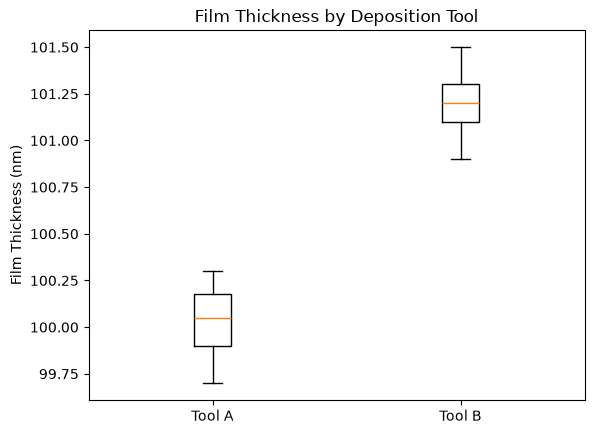

In [13]:
tool_a_values = tool_a.values
tool_b_values = tool_b.values

plt.boxplot(
    [tool_a_values, tool_b_values],
    tick_labels=["Tool A", "Tool B"]
)

plt.ylabel("Film Thickness (nm)")
plt.title("Film Thickness by Deposition Tool")

plt.show()